# A2 EDA - inventory, gear, seasonality, regions, quality

Silver interactions and vessels only. Exploration lives here. No pipeline logic, no transit drop, no spatial join (A3).

**Part 1:** what is the table, and who fishes? **Part 2:** when, where, and what is weird?


## Conventions

- Read `data/processed/interactions/` and `data/processed/vessels.parquet` (silver).
- `hive_partitioning=false` so `year` / `month` stay the integer columns silver wrote.
- Vessel join is **`(mmsi, year)`**. GFW v3 is one row per MMSI per year; joining on MMSI alone fans out rows.
- `fishing_ratio` stays in the table. Low-ratio steaming lanes are a finding, not a filter (B1).


In [ ]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from src.paths import INTERACTIONS_DIR, VESSELS_PATH

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

INTERACTIONS = (INTERACTIONS_DIR.as_posix() + "/**/*.parquet")
VESSELS = VESSELS_PATH.as_posix()

assert INTERACTIONS_DIR.exists(), INTERACTIONS_DIR
assert VESSELS_PATH.exists(), VESSELS_PATH
print("interactions", INTERACTIONS_DIR)
print("vessels     ", VESSELS_PATH)


interactions C:\Users\isvan\OneDrive\Documents\Van-Cave\Machine Learning\Fisheries\data\processed\interactions
vessels      C:\Users\isvan\OneDrive\Documents\Van-Cave\Machine Learning\Fisheries\data\processed\vessels.parquet


## 1. Inventory

One row is a vessel × 0.1° cell × day. `hours` is AIS presence; `fishing_hours` is the subset GFW labelled as fishing.


In [2]:
inventory = con.execute(
    """
    SELECT
      year,
      count(*) AS rows,
      count(DISTINCT mmsi) AS vessels,
      count(DISTINCT cell_id) AS cells,
      min(date) AS min_date,
      max(date) AS max_date,
      round(sum(hours), 1) AS hours,
      round(sum(fishing_hours), 1) AS fishing_hours,
      round(100.0 * sum(fishing_hours) / nullif(sum(hours), 0), 2) AS fishing_pct_of_presence
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1
    ORDER BY 1
    """,
    [INTERACTIONS],
).df()

totals = con.execute(
    """
    SELECT
      count(*) AS rows,
      count(DISTINCT mmsi) AS vessels,
      count(DISTINCT cell_id) AS cells,
      round(sum(hours), 1) AS hours,
      round(sum(fishing_hours), 1) AS fishing_hours
    FROM read_parquet(?, hive_partitioning = false)
    """,
    [INTERACTIONS],
).df()

display(inventory)
display(totals)


,year,rows,vessels,cells,min_date,max_date,hours,fishing_hours,fishing_pct_of_presence
0,2023,84786933,96453,2040786,2023-01-01,2023-12-31,283508910.7,111710765.8,39.40
1,2024,84800259,94459,2002622,2024-01-01,2024-12-31,299056335.8,114380457.9,38.25


,rows,vessels,cells,hours,fishing_hours
0,169587192,117081,2341624,582565246.4,226091223.8


,bucket,rows,hours,fishing_hours
0,0,100048380,299234194.6,0.0
1,"(0, 0.05]",892076,11696101.3,279520.8
2,"(0.05, 0.25]",3160696,21924123.9,2981679.7
3,"(0.25, 0.50]",4197195,18549003.8,6974904.3
4,"(0.50, 0.90]",12674502,52375936.8,38715817.7
5,"(0.90, 1]",48614343,178785886.1,177139301.2


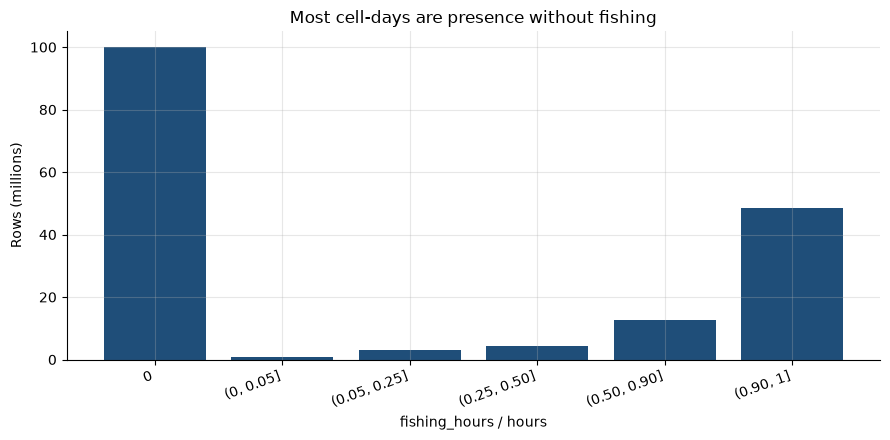

In [3]:
ratio_buckets = con.execute(
    """
    SELECT
      CASE
        WHEN fishing_ratio = 0 THEN '0'
        WHEN fishing_ratio <= 0.05 THEN '(0, 0.05]'
        WHEN fishing_ratio <= 0.25 THEN '(0.05, 0.25]'
        WHEN fishing_ratio <= 0.50 THEN '(0.25, 0.50]'
        WHEN fishing_ratio <= 0.90 THEN '(0.50, 0.90]'
        ELSE '(0.90, 1]'
      END AS bucket,
      count(*) AS rows,
      round(sum(hours), 1) AS hours,
      round(sum(fishing_hours), 1) AS fishing_hours
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1
    ORDER BY min(fishing_ratio)
    """,
    [INTERACTIONS],
).df()

display(ratio_buckets)

fig, ax = plt.subplots()
ax.bar(ratio_buckets["bucket"], ratio_buckets["rows"] / 1_000_000, color="#1f4e79")
ax.set_ylabel("Rows (millions)")
ax.set_xlabel("fishing_hours / hours")
ax.set_title("Most cell-days are presence without fishing")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Findings - inventory

- Two full years, almost the same size: **84.8M rows each**. 2023: 96,453 MMSIs and 2.04M cells; 2024: 94,459 MMSIs and 2.00M cells. Distinct MMSIs across both years are about **117k**, so a large share of vessels appear in both years.
- Presence hours are **283.5M (2023)** and **299.1M (2024)**. Fishing is **39.4%** and **38.3%** of presence respectively. 2024 has more presence hours and slightly less fishing share — treat year-on-year “effort up” as provisional (AIS coverage is non-stationary; 2024 classifications are provisional).
- **~100M rows (59%) have `fishing_ratio = 0`.** Those are steaming / sitting, not grounds. Another **48.6M rows** are almost pure fishing (`ratio > 0.9`). The interaction matrix (B1) will need a ratio threshold; this histogram is why. Do not drop them here — EDA still needs the transit mass.


## 2. Vessel join

GFW v3 is one metadata row per MMSI **per year**. Join on both keys or the interaction table fans out.


In [4]:
join_coverage = con.execute(
    """
    WITH i AS (
      SELECT mmsi, year, hours, fishing_hours
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT
      count(*) AS rows,
      count(*) FILTER (WHERE v.mmsi IS NULL) AS unmatched_rows,
      round(100.0 * count(*) FILTER (WHERE v.mmsi IS NULL) / count(*), 4) AS unmatched_row_pct,
      count(DISTINCT i.mmsi) AS interaction_mmsis,
      count(DISTINCT i.mmsi) FILTER (WHERE v.mmsi IS NULL) AS unmatched_mmsis
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    """,
    [INTERACTIONS, VESSELS],
).df()

unmatched = con.execute(
    """
    WITH i AS (
      SELECT DISTINCT mmsi, year
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT i.mmsi, i.year
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    WHERE v.mmsi IS NULL
    ORDER BY i.year, i.mmsi
    """,
    [INTERACTIONS, VESSELS],
).df()

display(join_coverage)
display(unmatched)


,rows,unmatched_rows,unmatched_row_pct,interaction_mmsis,unmatched_mmsis
0,169587192,13879,0.0082,117081,3


,mmsi,year
0,273873400,2023
1,412217999,2023
2,431002015,2023
3,273873400,2024
4,431002015,2024


### Findings — join

- **13,879 unmatched rows (0.008%)** and **3 unmatched MMSIs**. Gear charts below label those as `(unmatched)` rather than dropping them.
- The join is safe at this grain. The v3 fan-out warning in DATA.md is real for a sloppy join, not for `(mmsi, year)`.


## 3. Effort by gear

`vessel_class_gfw` is the strongest metadata field. If a later ALS latent space does not roughly separate these classes, the model is wrong.


,gear,rows,vessels,fishing_hours,hours,fishing_share_pct
0,trawlers,70208122,48436,120382763.7,247276689.7,53.245217
1,fishing,27915809,24587,38695432.9,126227499.9,17.114965
2,drifting_longlines,26435680,8162,25299648.3,49623777.5,11.190018
3,set_gillnets,8906360,10602,12339950.6,45510762.6,5.457952
4,set_longlines,8375284,8512,10699315.4,28476779.9,4.732300
5,fixed_gear,5104811,5011,6627654.0,23173619.1,2.931407
6,squid_jigger,6799998,1325,3032030.4,12863029.0,1.341065
7,other_purse_seines,6214915,3423,2613250.8,18347437.2,1.155839
8,pole_and_line,3353120,2745,2337178.4,10460710.3,1.033732
9,dredge_fishing,992484,1895,1645308.2,6228956.1,0.727719


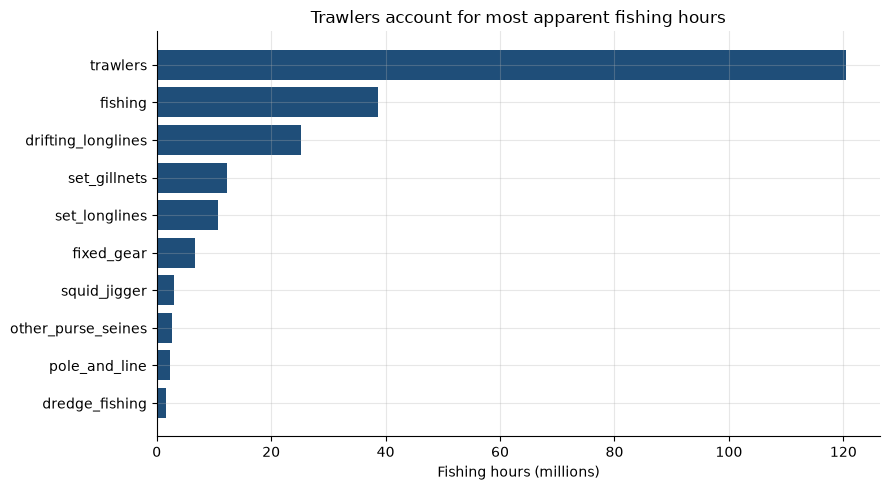

In [5]:
gear = con.execute(
    """
    WITH i AS (
      SELECT mmsi, year, hours, fishing_hours
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT
      coalesce(v.vessel_class_gfw, '(unmatched)') AS gear,
      count(*) AS rows,
      count(DISTINCT i.mmsi) AS vessels,
      round(sum(i.fishing_hours), 1) AS fishing_hours,
      round(sum(i.hours), 1) AS hours
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    GROUP BY 1
    ORDER BY fishing_hours DESC
    """,
    [INTERACTIONS, VESSELS],
).df()

gear["fishing_share_pct"] = 100.0 * gear["fishing_hours"] / gear["fishing_hours"].sum()
display(gear)

top = gear.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["gear"], top["fishing_hours"] / 1_000_000, color="#1f4e79")
ax.set_xlabel("Fishing hours (millions)")
ax.set_title("Trawlers account for most apparent fishing hours")
plt.tight_layout()
plt.show()


### Findings - gear

- **Trawlers: 53% of fishing hours** (120.4M of 226.1M) from 48k vessels. They will dominate a global-popularity baseline. Popularity-by-gear is the baseline that matters; ALS has to beat *trawlers fish the shelf*, not a flat top-N over all gears.
- Next are the generic class **`fishing`** (38.7M h, 24.6k vessels) and **`drifting_longlines`** (25.3M h, only 8.2k vessels - high hours per hull). Set gillnets and set longlines follow.
- **Rare gears** (trollers, other_seines, seiners, purse_seines) are small in hours. Cold-start and coverage metrics should not pretend they have the same support as trawlers. `(unmatched)` is negligible (5.9k fishing hours).
- `fishing` as a class is a GFW leftover bucket, not a gear. Treat it as low-information metadata, not as a behavioural type.


## 4. Seasonality

Monthly fishing hours, 2023 vs 2024. A rise may be AIS reception, not more fishing (DATA.md). 2024 classifications are provisional.

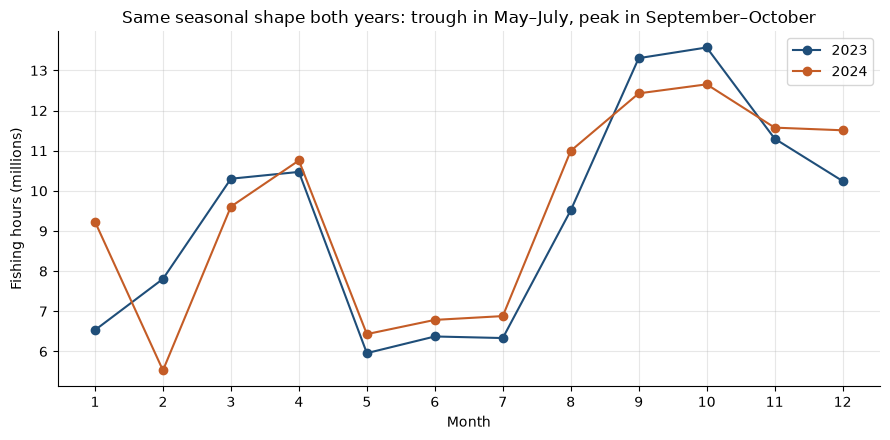

In [ ]:
monthly = con.execute(
    """
    SELECT year, month,
           sum(fishing_hours) AS fishing_hours,
           sum(hours) AS hours
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1, 2
    ORDER BY 1, 2
    """,
    [INTERACTIONS],
).df()

fig, ax = plt.subplots()
for year, colour in [(2023, "#1f4e79"), (2024, "#c45c26")]:
    sub = monthly[monthly["year"] == year]
    ax.plot(sub["month"], sub["fishing_hours"] / 1e6, marker="o", color=colour, label=str(year))
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Fishing hours (millions)")
ax.set_title("Same seasonal shape both years: trough in May–July, peak in September–October")
ax.legend()
plt.tight_layout()
plt.show()


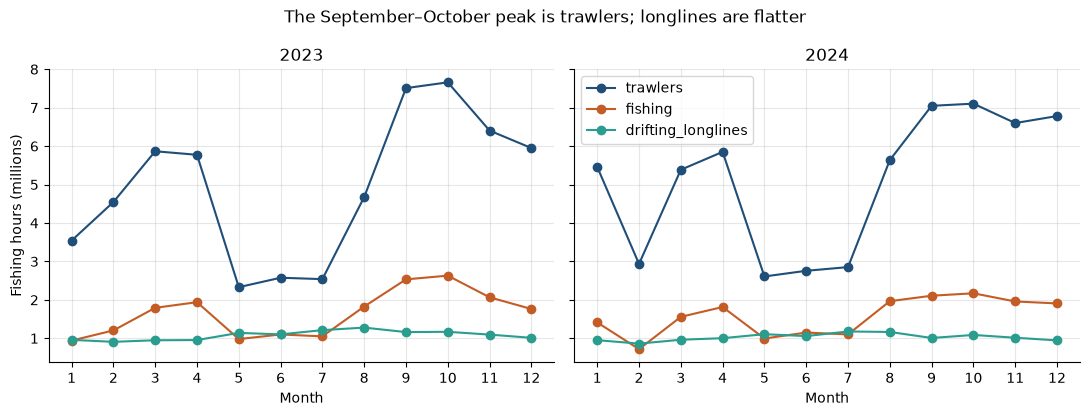

In [ ]:
monthly_gear = con.execute(
    """
    WITH i AS (
      SELECT mmsi, year, month, fishing_hours
      FROM read_parquet(?, hive_partitioning = false)
    )
    SELECT i.year, i.month,
           coalesce(v.vessel_class_gfw, '(unmatched)') AS gear,
           sum(i.fishing_hours) AS fishing_hours
    FROM i
    LEFT JOIN read_parquet(?) v ON i.mmsi = v.mmsi AND i.year = v.year
    WHERE coalesce(v.vessel_class_gfw, '(unmatched)') IN (
      'trawlers', 'fishing', 'drifting_longlines'
    )
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
    """,
    [INTERACTIONS, VESSELS],
).df()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, year in zip(axes, (2023, 2024)):
    sub = monthly_gear[monthly_gear["year"] == year]
    for gear, colour in [
        ("trawlers", "#1f4e79"),
        ("fishing", "#c45c26"),
        ("drifting_longlines", "#2a9d8f"),
    ]:
        g = sub[sub["gear"] == gear]
        ax.plot(g["month"], g["fishing_hours"] / 1e6, marker="o", color=colour, label=gear)
    ax.set_xticks(range(1, 13))
    ax.set_title(str(year))
    ax.set_xlabel("Month")
axes[0].set_ylabel("Fishing hours (millions)")
axes[1].legend(loc="upper left")
fig.suptitle("The September–October peak is trawlers; longlines are flatter")
plt.tight_layout()
plt.show()


### Findings — seasonality

- Both years share the same shape: **May–July trough (~6M fishing hours/month)** and **September–October peak (~13M)**. A temporal split that puts Q4 in test (README) therefore tests the *busy* season, not a random month.
- **Trawlers create the peak.** Drifting longlines sit near 1M hours every month. The generic `fishing` class tracks trawlers more than longlines.
- 2024 January is higher than 2023 January (9.2 vs 6.5M) and 2024 February is lower (5.5 vs 7.8M). Do not read that as a stock collapse or boom — AIS coverage is non-stationary and 2024 is provisional.


## 5. Top regions

Raw 0.1° cells are too many to plot. Aggregate fishing hours to 1°, list the hottest cells, and measure a coarse Australian bbox (not an EEZ join — that is A3).

Australian mainland-ish bbox used here: latitude **[-50, -10]**, longitude **[110, 160]**. The GEBCO file on disk is a smaller southern strip (58.2°S–30.8°S); that share is reported separately.

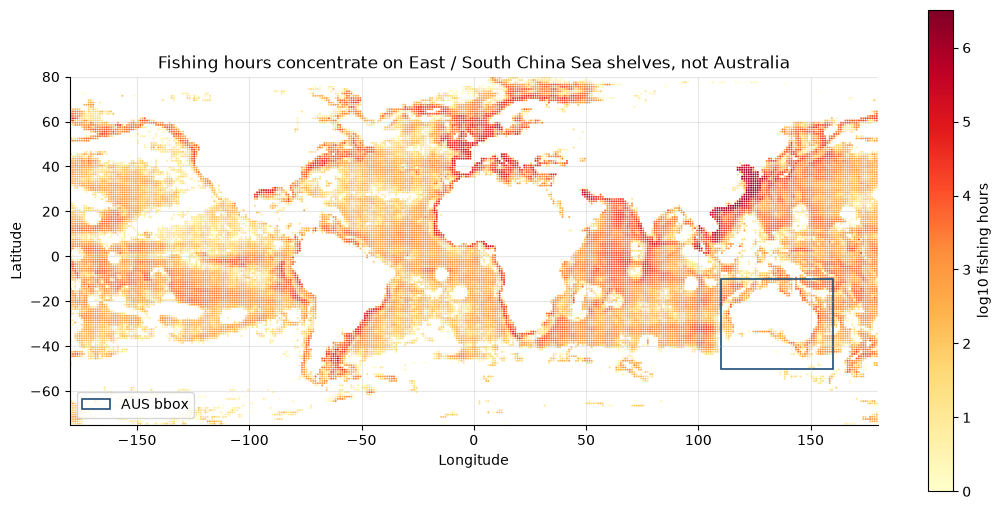

,lat,lon,fish_m
0,35.5,119.5,3.225
1,30.5,123.5,3.008
2,28.5,122.5,2.990
3,22.5,116.5,2.775
4,35.5,120.5,2.745
5,31.5,123.5,2.492
6,29.5,122.5,2.447
7,21.5,113.5,2.269
8,29.5,123.5,2.174
9,23.5,117.5,2.019


In [ ]:
import numpy as np
from matplotlib.patches import Rectangle

deg = con.execute(
    """
    SELECT
      floor(cell_ll_lat) + 0.5 AS lat,
      floor(cell_ll_lon) + 0.5 AS lon,
      sum(fishing_hours) AS fishing_hours
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1, 2
    HAVING sum(fishing_hours) > 0
    """,
    [INTERACTIONS],
).df()

fig, ax = plt.subplots(figsize=(11, 5.2))
sc = ax.scatter(
    deg["lon"],
    deg["lat"],
    c=np.log10(deg["fishing_hours"].clip(lower=1)),
    s=2,
    cmap="YlOrRd",
    linewidths=0,
    rasterized=True,
)
ax.add_patch(Rectangle((110, -50), 50, 40, fill=False, edgecolor="#1f4e79", linewidth=1.2, label="AUS bbox"))
ax.set_xlim(-180, 180)
ax.set_ylim(-75, 80)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Fishing hours concentrate on East / South China Sea shelves, not Australia")
fig.colorbar(sc, ax=ax, label="log10 fishing hours")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

top_deg = (
    deg.sort_values("fishing_hours", ascending=False)
    .head(12)
    .assign(fish_m=lambda d: (d["fishing_hours"] / 1e6).round(3))
    [["lat", "lon", "fish_m"]]
)
display(top_deg.reset_index(drop=True))


In [ ]:
top_cells = con.execute(
    """
    SELECT cell_id, cell_ll_lat, cell_ll_lon,
           round(sum(fishing_hours), 1) AS fishing_hours
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1, 2, 3
    ORDER BY fishing_hours DESC
    LIMIT 10
    """,
    [INTERACTIONS],
).df()

scope = con.execute(
    """
    SELECT
      round(sum(fishing_hours) / 1e6, 2) AS world_fish_m,
      round(sum(fishing_hours) FILTER (
        WHERE cell_ll_lat BETWEEN -50 AND -10
          AND cell_ll_lon BETWEEN 110 AND 160
      ) / 1e6, 2) AS aus_bbox_fish_m,
      round(100.0 * sum(fishing_hours) FILTER (
        WHERE cell_ll_lat BETWEEN -50 AND -10
          AND cell_ll_lon BETWEEN 110 AND 160
      ) / sum(fishing_hours), 3) AS aus_bbox_pct,
      round(100.0 * sum(fishing_hours) FILTER (
        WHERE cell_ll_lat BETWEEN -58.195 AND -30.783
          AND cell_ll_lon BETWEEN 99.967 AND 159.976
      ) / sum(fishing_hours), 3) AS gebco_file_bbox_pct
    FROM read_parquet(?, hive_partitioning = false)
    """,
    [INTERACTIONS],
).df()

display(top_cells)
display(scope)


,cell_id,cell_ll_lat,cell_ll_lon,fishing_hours
0,35.0_119.3,35.0,119.3,664957.6
1,29.2_121.9,29.2,121.9,397983.2
2,35.1_119.3,35.1,119.3,338206.9
3,29.9_122.2,29.9,122.2,260833.4
4,35.3_119.4,35.3,119.4,222415.8
5,22.7_114.5,22.7,114.5,199409.3
6,10.3_107.2,10.3,107.2,173207.4
7,10.2_107.2,10.2,107.2,168807.1
8,10.2_107.1,10.2,107.1,156421.1
9,35.0_119.4,35.0,119.4,130461.2


,world_fish_m,aus_bbox_fish_m,aus_bbox_pct,gebco_file_bbox_pct
0,226.09,1.28,0.567,0.32


### Findings — regions

- Hottest 1° bins and cells sit on the **Yellow Sea / East China Sea / South China Sea** shelf (e.g. `35.0_119.3`, ~665k fishing hours). That is industrial coastal effort, not the Southern Ocean.
- The coarse **Australian bbox is 0.57% of global fishing hours** (1.28M of 226M). The GEBCO file already downloaded covers an even thinner southern strip (**0.32%**). A3’s “Australian EEZ for the core model” is a small, fast matrix — and it is *not* where most of the world’s apparent effort is.
- Keep the global silver table as-is. Scope to Australia at matrix / model time (or after a real EEZ join), not by deleting bronze/silver.


## 6. Quality surprises

The plan flags cells with absurd hour totals, MMSIs active 400 days in a 365-day year, and noisy user keys. Check them on silver, do not “fix” them here.

,rows_hours_gt_24,row_pct,presence_hours_m,fishing_hours_m,max_hours,rows_fishing_gt_24
0,3516586,2.07,90.33,11.02,47.97,241608


,year,vessels,days_gt_365,days_gt_366,max_days,mean_days,median_days,p99_days
0,2023,96453,0,0,365,147.4,127,365
1,2024,94459,1844,0,366,156.9,138,366


,digits,rows,vessels
0,2,354,1
1,3,14892,22
2,4,41966,83
3,5,126738,189
4,6,46462,99
5,7,380012,440
6,8,448782,590
7,9,168522959,115646
8,10,5027,11


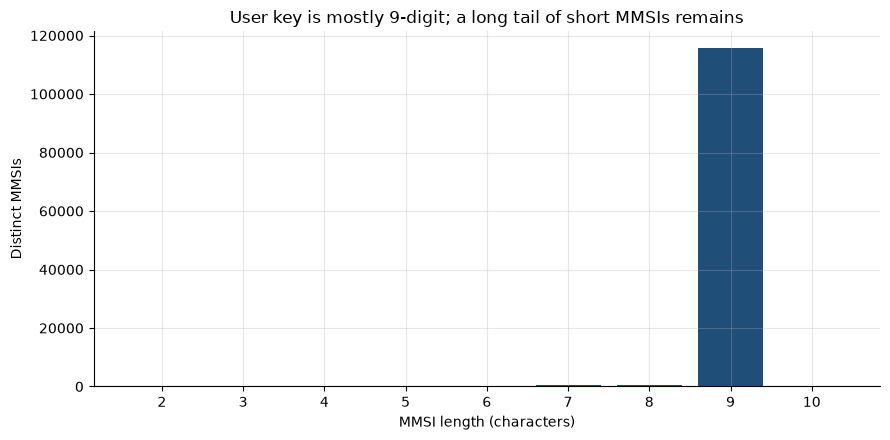

In [ ]:
hours_tail = con.execute(
    """
    SELECT
      count(*) FILTER (WHERE hours > 24) AS rows_hours_gt_24,
      round(100.0 * count(*) FILTER (WHERE hours > 24) / count(*), 2) AS row_pct,
      round(sum(hours) FILTER (WHERE hours > 24) / 1e6, 2) AS presence_hours_m,
      round(sum(fishing_hours) FILTER (WHERE hours > 24) / 1e6, 2) AS fishing_hours_m,
      round(max(hours), 2) AS max_hours,
      count(*) FILTER (WHERE fishing_hours > 24) AS rows_fishing_gt_24
    FROM read_parquet(?, hive_partitioning = false)
    """,
    [INTERACTIONS],
).df()

active_days = con.execute(
    """
    WITH d AS (
      SELECT mmsi, year, count(DISTINCT date) AS days
      FROM read_parquet(?, hive_partitioning = false)
      GROUP BY 1, 2
    )
    SELECT
      year,
      count(*) AS vessels,
      count(*) FILTER (WHERE days > 365) AS days_gt_365,
      count(*) FILTER (WHERE days > 366) AS days_gt_366,
      max(days) AS max_days,
      round(avg(days), 1) AS mean_days,
      approx_quantile(days, 0.5) AS median_days,
      approx_quantile(days, 0.99) AS p99_days
    FROM d
    GROUP BY 1
    ORDER BY 1
    """,
    [INTERACTIONS],
).df()

mmsi_len = con.execute(
    """
    SELECT
      length(mmsi) AS digits,
      count(*) AS rows,
      count(DISTINCT mmsi) AS vessels
    FROM read_parquet(?, hive_partitioning = false)
    GROUP BY 1
    ORDER BY 1
    """,
    [INTERACTIONS],
).df()

display(hours_tail)
display(active_days)
display(mmsi_len)

fig, ax = plt.subplots()
ax.bar(mmsi_len["digits"].astype(str), mmsi_len["vessels"], color="#1f4e79")
ax.set_xlabel("MMSI length (characters)")
ax.set_ylabel("Distinct MMSIs")
ax.set_title("User key is mostly 9-digit; a long tail of short MMSIs remains")
plt.tight_layout()
plt.show()


### Findings — quality

- **`hours > 24` is real and common: 3.52M rows (2.1%), max 48.0 hours.** Those rows hold 90M presence hours but only 11M fishing hours — mostly sitting/parked, not frantic fishing. GFW assigns elapsed time since the previous AIS ping, so a quiet vessel can dump more than a calendar day into one cell-day. Keep the rows. Do not cap for EDA. A B1 transit filter on *ratio* will catch most of this anyway.
- **No MMSI has more distinct dates than the calendar.** 2023 max is 365; 2024 max is 366 (leap year). 1,844 vessels have a row on every day of 2024. The “400 days in a 365-day year” scare does not show up at this grain.
- **Non-9-digit MMSIs: ~1,435 vessels and ~1.06M rows (~0.6%).** That is user-key noise (DATA.md). Do not drop them in silver; they are a known limitation of treating MMSI as a unique user.

## A2 wrap

You should now be able to say, without looking it up: trawlers are half the fishing hours; effort troughs in winter (NH) and peaks in autumn; the map is East Asian shelves, not Australia (~0.6% of hours in a coarse AUS bbox); most rows are transit (`fishing_ratio = 0`); `hours > 24` is elapsed-time binning, not a 400-day MMSI bug.
